This tutorial will hopefully give you a better understanding of how BLISS functions by detecting Voyager 1 with BLISS. This will be done with radio data gathered by Breakthrough Listen at the Green Bank Telescope pointing at Voyager 1. Using BLISS's technosignature - in this case which is an artificial radio signal indicative of technology and life - search pipeline, we will be able to detect the presence of Voyager 1 - nearly 170 AUs away.

As a refresher, in order to understand what a technosignature is, it is helpful to understand what a technosignature is not. Human-generated radio frequency interference (RFI) from cell phones, Wi-Fi, radar, etc, is much more abundant and powerful than potential alien-generated signals. Our goal is to filter away RFI. There are two techniques which are used to filter away RFI and other signals - in the form natural phenomena. 

1.) Pointing the telescope ON and OFF a Target (aka "Nodding")
    This is how SETI searches are done. By pointing a radio telescope, like the Green Bank Telescope, at a target (Voyager 1 in our case) for 5 minutes and then pointing the telescope at a different part of the sky and then repeating this process, we can assume what signals are RFI. Specifically, most RFI should appear regardless of which direction the telescope is pointed in, while signals from space should appear only when the telescope is pointed directly at them. 
    If we a signal present in all of the ON target observations and not in the OFF target observations, we can be confident that the signal is not a form of RFI. 
    Each one of these 5 minute periods is known as a cadence. 

    The specific pattern is: 
    1 "ON" --> 1 "OFF" --> 2 "ON" --> 2 "OFF" --> 3 "ON" --> 3 "OFF". 

    This means the total observation time is 30 minutes. 


2.) Nonzero Doppler Drift
    The applications of Doppler Shift can be found everywhere. An example is seen with a vehicle traveling at a constant velocity sounding a horn approaches and recedes from an observer. The observer will hear a constant higher pitched sound as the car approaches and a constant lower frequency as soon as the vehicle passes the observer. 
    
    Doppler Drift differs in the sense that this velocity is no longer constant. Rather, it is changing as a function of time - indicative of some acceleration. This results in a perceived frequency that changes over time.

    Since light also has wave features just like sound, this concept also applies to astronomy signals. The Earth is rotating and orbiting at a non-constant velocity and objects of interest in space (like exoplanets and stars) also have their own changing velocity. Because most objects on Earth generally have a constant velocity relative Earth, most RFI will not have a Doppler Drift. BLISS will use this fact to dismiss potential signals. This assumes that ET have decided to emit signals at constant frequencies.



Telescope Data
    Voyager 1 data collected by the Green Bank Telescope on July 16th, 2020 will be used for this demo. 

BLISS (Breakthrough Listen Interesting Signal Search)
    As mentioned earlier, BLISS will allow us to detect Voyager 1 through its technosignature search pipeline. For potential technosignatures, BLISS will "de-drift" these signals. Since our cadences are only 5 minutes, we can assume the acceleration of targets relative to us is fairly constant, giving us in theory linearly doppler drifting signals. De-drifting these signals means we can the original constant frequency emitted by ET. BLISS also calculates the drift rate - the time rate at which a particular's frequency changes (in units of Hz/s). BLISS also calculates some other important information which we will look at once we run it. 

Using BLISS
    While there are Python bindings for BLISS, they are currently in development. However, we can still use the command line to invoke BLISS. In order to do this in an organized manner, we will be invoking terminal commands through Python. We can also plot and graph data to verify visually what BLISS is reporting. We will be using the "bliss_find_hits" command. Feel free to type "bliss_find_hits -h" to look at all of the various flags BLISS has. For our case of finding Voyager 1, we will be using only a few of the flags. Here is the command we will eventually call:

    console = 'bliss_find_hits ' + f'/datax/scratch/abrara/Voyager_Data/{cadence}' + f' -d cuda:0 -s 33 -md -4 -MD 4 --number-coarse 1 --nchan-per-coarse 1048576 --output -'

    - The first parameter is the file directory cadence (stored as an h5)
    - The -d flag refers to the CUDA device ids of GPUs. If you only have 1 GPU, the device id is 0. If you do not have a GPU, BLISS will use the CPU instead, though it may run slower. 
    - The -s flag corresponds to the minimum Signal to Noise Ratio (SNR) of a technosignature. In this case, if a technosignature has a SNR value lower than 33, then the technosignature is discarded. 
    - The -md and -MD flags correspond to the minimum and maximum drift rate of a technosignature, respectively (drift rates can be both positive and negative).  In this case, if a technosignature has a drift rate in the range [-4,4] Hz/s, then it will not be disregarded. Otherwise, it is discarded. 
    - The --number-coarse flag corresponds to the number of coarse channels present in the h5 file. For this dataset, all of the files are single coarse, so there is only one coarse channel per file.
    - The --nchan-per-coarse flag corresponds to the number of fine frequency channels in the dataset. Since radio data is fundamentally continuous, but computers store data discretely, we assign each channel a small range of frequencies. For the data we have, each course channel contains 187.5 MHz worth of frequency data. This means each channel is about 180 hz wide. 
    - The --output flag specifies the filename of the resultant dat file. This dat file will contain the results of the earch. 

    We will be running this command on all 6 of the cadences. Then we will use the aforementioned techniques to filter RFI. At the end, we will hopefully find Voyager 1's signal and information about it from BLISS. Just to verify what BLISS is reporting, we will also look at the radio data's power spectrum using blimpy. 

    

    

Found a usable device
Found a usable device
Found a usable device
Found a usable device
INFO: HDF5 looking for filter plugins in: 
	'/usr/lib/x86_64-linux-gnu/hdf5/serial/plugin '
INFO: Got source name VOYAGER-1
INFO: using cuda:1 :: NVIDIA RTX A4000 (UUID: d2c9316d9bdf6bfaf7bac661a338ae78)
INFO: Searching 784 drift rates from -4.0000682504877005 Hz/sec to 4.0000682504877005 Hz/sec in increments of 0.010204255741040053 Hz/sec
scan has 6 hits
hit: .start_freq_MHz=8419.521181 (.index=667706), .drift_rate_Hz_per_second=-3.908230 (.index=9), .SNR=34.741585, .power=0, bandwidth=55.9
hit: .start_freq_MHz=8419.520237 (.index=668097), .drift_rate_Hz_per_second=-0.367353 (.index=356), .SNR=123.494507, .power=0, bandwidth=352.0
hit: .start_freq_MHz=8419.565233 (.index=651993), .drift_rate_Hz_per_second=-0.367353 (.index=356), .SNR=128.387482, .power=0, bandwidth=346.5
hit: .start_freq_MHz=8419.520041 (.index=668103), .drift_rate_Hz_per_second=1.000017 (.index=490), .SNR=57.992180, .power=0, band

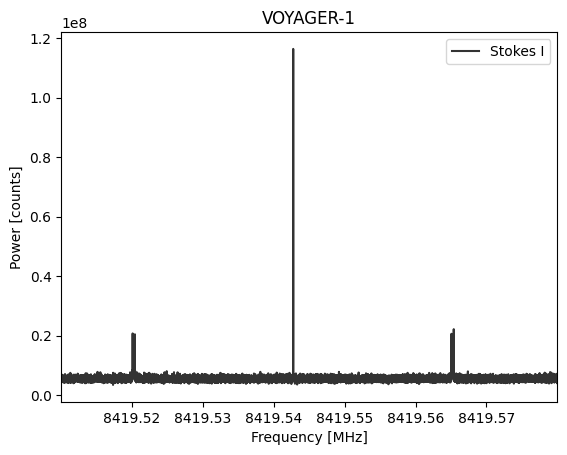

Found a usable device
Found a usable device
Found a usable device
Found a usable device
INFO: HDF5 looking for filter plugins in: 
	'/usr/lib/x86_64-linux-gnu/hdf5/serial/plugin '
INFO: Got source name VOYAGER-1 OFF
INFO: using cuda:1 :: NVIDIA RTX A4000 (UUID: d2c9316d9bdf6bfaf7bac661a338ae78)
INFO: Searching 784 drift rates from -4.0000682504877005 Hz/sec to 4.0000682504877005 Hz/sec in increments of 0.010204255741040053 Hz/sec
scan has 0 hits
extracting integration 0...


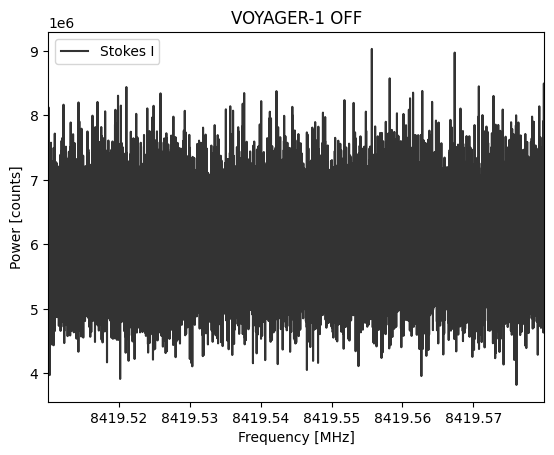

Found a usable device
Found a usable device
Found a usable device
Found a usable device
INFO: HDF5 looking for filter plugins in: 
	'/usr/lib/x86_64-linux-gnu/hdf5/serial/plugin '
INFO: Got source name VOYAGER-1
INFO: using cuda:1 :: NVIDIA RTX A4000 (UUID: d2c9316d9bdf6bfaf7bac661a338ae78)
INFO: Searching 784 drift rates from -4.0000682504877005 Hz/sec to 4.0000682504877005 Hz/sec in increments of 0.010204255741040053 Hz/sec
scan has 5 hits
hit: .start_freq_MHz=8419.564834 (.index=652078), .drift_rate_Hz_per_second=-0.397966 (.index=353), .SNR=43.575584, .power=0, bandwidth=16.8
hit: .start_freq_MHz=8419.519840 (.index=668182), .drift_rate_Hz_per_second=-0.397966 (.index=353), .SNR=43.925568, .power=0, bandwidth=16.8
hit: .start_freq_MHz=8419.542499 (.index=660073), .drift_rate_Hz_per_second=-0.397966 (.index=353), .SNR=358.973969, .power=0, bandwidth=19.6
hit: .start_freq_MHz=8419.520161 (.index=668067), .drift_rate_Hz_per_second=-0.408170 (.index=352), .SNR=46.225922, .power=0, band

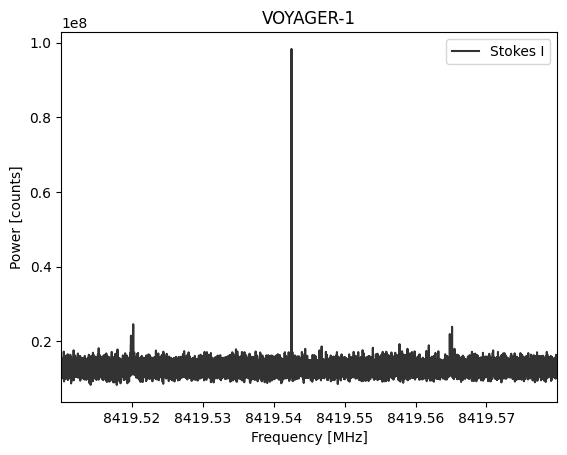

Found a usable device
Found a usable device
Found a usable device
Found a usable device
INFO: HDF5 looking for filter plugins in: 
	'/usr/lib/x86_64-linux-gnu/hdf5/serial/plugin '
INFO: Got source name VOYAGER-1 OFF
INFO: using cuda:1 :: NVIDIA RTX A4000 (UUID: d2c9316d9bdf6bfaf7bac661a338ae78)
INFO: Searching 784 drift rates from -4.0000682504877005 Hz/sec to 4.0000682504877005 Hz/sec in increments of 0.010204255741040053 Hz/sec
scan has 0 hits
extracting integration 0...


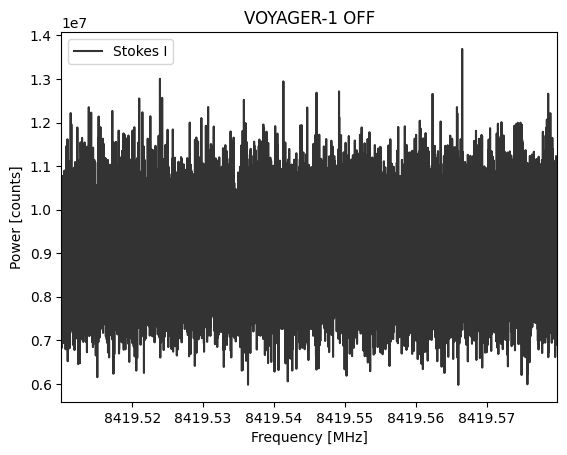

Found a usable device
Found a usable device
Found a usable device
Found a usable device
INFO: HDF5 looking for filter plugins in: 
	'/usr/lib/x86_64-linux-gnu/hdf5/serial/plugin '
INFO: Got source name VOYAGER-1
INFO: using cuda:1 :: NVIDIA RTX A4000 (UUID: d2c9316d9bdf6bfaf7bac661a338ae78)
INFO: Searching 784 drift rates from -4.0000682504877005 Hz/sec to 4.0000682504877005 Hz/sec in increments of 0.010204255741040053 Hz/sec
scan has 6 hits
hit: .start_freq_MHz=8419.564585 (.index=652171), .drift_rate_Hz_per_second=-0.418374 (.index=351), .SNR=106.714668, .power=0, bandwidth=47.5
hit: .start_freq_MHz=8419.519588 (.index=668275), .drift_rate_Hz_per_second=-0.428579 (.index=350), .SNR=107.228737, .power=0, bandwidth=47.5
hit: .start_freq_MHz=8419.519594 (.index=668288), .drift_rate_Hz_per_second=0.846953 (.index=475), .SNR=45.396191, .power=0, bandwidth=374.4
hit: .start_freq_MHz=8419.563839 (.index=652432), .drift_rate_Hz_per_second=3.632715 (.index=748), .SNR=33.054749, .power=0, band

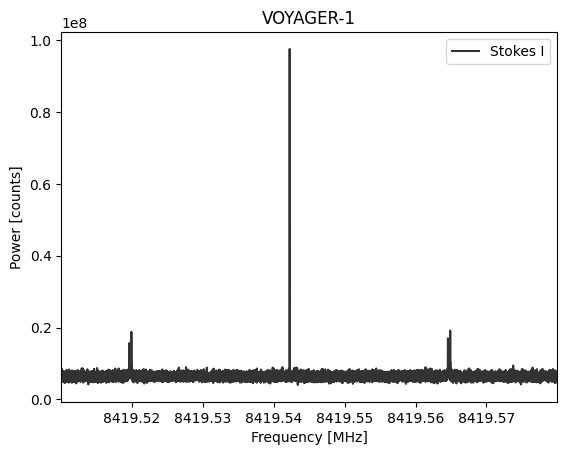

Found a usable device
Found a usable device
Found a usable device
Found a usable device
INFO: HDF5 looking for filter plugins in: 
	'/usr/lib/x86_64-linux-gnu/hdf5/serial/plugin '
INFO: Got source name VOYAGER-1 OFF
INFO: using cuda:1 :: NVIDIA RTX A4000 (UUID: d2c9316d9bdf6bfaf7bac661a338ae78)
INFO: Searching 784 drift rates from -4.0000682504877005 Hz/sec to 4.0000682504877005 Hz/sec in increments of 0.010204255741040053 Hz/sec
scan has 0 hits
extracting integration 0...


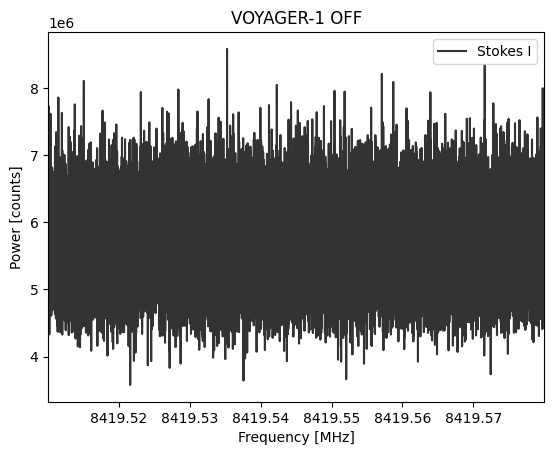

In [ ]:

import os
import matplotlib.pyplot as plt
from blimpy import Waterfall
import numpy as np
%matplotlib inline

#These parameters represent the range of frequencies we wish to view in the power spectrum.
f_start = 8419.51
f_stop = 8419.58
OUTDIR = '/datax/scratch/abrara/bliss_out/'

#These are the filenames of all of the ON cadences.
ONCadences = [ "single_coarse_guppi_59046_80036_DIAG_VOYAGER-1_0011.rawspec.0000.h5",
"single_coarse_guppi_59046_80672_DIAG_VOYAGER-1_0013.rawspec.0000.h5",
"single_coarse_guppi_59046_81310_DIAG_VOYAGER-1_0015.rawspec.0000.h5"]

#These are the filenames of all of the OFF cadences.
OFFCadences = ["single_coarse_guppi_59046_80354_DIAG_VOYAGER-1_0012.rawspec.0000.h5", 
               "single_coarse_guppi_59046_80989_DIAG_VOYAGER-1_0014.rawspec.0000.h5",
               "single_coarse_guppi_59046_81628_DIAG_VOYAGER-1_0016.rawspec.0000.h5"]


# For each cadence, we will use BLISS to look for technosignatures.
for i in range(3):
    #ON Cadence 
    #Run BLISS
    console = 'bliss_find_hits ' + f'/datax/scratch/abrara/Voyager_Data/{ONCadences[i]}' + f' -d cuda:1 -s 33 -md -4 -MD 4 --number-coarse 1 --nchan-per-coarse 1048576 --output -'
    os.system(console)

    #Plot Spectrum
    obs = Waterfall(f'/datax/scratch/abrara/Voyager_Data/{ONCadences[i]}', f_start, f_stop)
    plt.figure()
    obs.plot_spectrum(f_start=f_start, f_stop=f_stop) 
    plt.show()

    #OFF Cadence
    #Run BLISS
    console = 'bliss_find_hits ' + f'/datax/scratch/abrara/Voyager_Data/{OFFCadences[i]}' + f' -d cuda:1 -s 33 -md -4 -MD 4 --number-coarse 1 --nchan-per-coarse 1048576 --output -'
    os.system(console)

    #Plot Spectrum
    obs = Waterfall(f'/datax/scratch/abrara/Voyager_Data/{OFFCadences[i]}', f_start, f_stop)
    plt.figure()
    obs.plot_spectrum(f_start=f_start, f_stop=f_stop) 
    plt.show()
       
       
   



It seems that BLISS found zero hits on the OFF cadences, and about 5-6 hits for the ON cadences. This is a good sign, as BLISS has not mistakenly detected any RFI. Looking at the OFF cadences gives us insight into how RFI/noise can look to BLISS.

Looking at the power spectrum for the ON cadences, we see 3 peaks. The tall spike is the carrier frequency and the two smaller spikes are sidebands with information about Voyager 1. Yet, we are getting 5-6 hits on the ON cadences. Logically, the three peaks should have the same drift rate, as the frequencies are all coming from Voyager One. Looking at our results, we can see that the multiple signals have similar drift rates. This suggests that they are coming from Voyager One. For the first ON cadence it is puzzling seeing 6 hits with similar drift rates, but this most likely due to BLISS accidentally duplicating the same hit. Nevertheless, we can modify our SNR to be a higher value to filter out these non-Voyager signals.

